In [32]:
# ============================================================
# STRATÉGIE 3 BACK TRANSACTION- BLOC 1: INSTALLATION ET CHARGEMENT
# ============================================================

print("="*70)
print("STRATÉGIE 3: BACK-TRANSLATION")
print("="*70)

# Installer les bibliothèques nécessaires
!pip install sentencepiece sacremoses -q

from transformers import MarianMTModel, MarianTokenizer
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import time

# ============================================================
# 1. CHARGEMENT DES MODÈLES DE TRADUCTION
# ============================================================

print("\n1. Chargement des modèles de traduction...")

# Modèle: Arabe → Français
model_name_ar_fr = "Helsinki-NLP/opus-mt-ar-fr"
tokenizer_ar_fr = MarianTokenizer.from_pretrained(model_name_ar_fr)
model_ar_fr = MarianMTModel.from_pretrained(model_name_ar_fr)

# Modèle: Français → Arabe
model_name_fr_ar = "Helsinki-NLP/opus-mt-fr-ar"
tokenizer_fr_ar = MarianTokenizer.from_pretrained(model_name_fr_ar)
model_fr_ar = MarianMTModel.from_pretrained(model_name_fr_ar)

print(f"   ✓ Modèle Arabe→Français chargé")
print(f"   ✓ Modèle Français→Arabe chargé")

# Déplacer sur GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ar_fr = model_ar_fr.to(device)
model_fr_ar = model_fr_ar.to(device)
print(f"   ✓ Modèles sur: {device}")

STRATÉGIE 3: BACK-TRANSLATION
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 19.8 MB/s eta 0:00:00

1. Chargement des modèles de traduction...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/918k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/824k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/307M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

   ✓ Modèle Arabe→Français chargé
   ✓ Modèle Français→Arabe chargé
   ✓ Modèles sur: cuda


In [33]:
# ============================================================
# STRATÉGIE 3 - BLOC 2: SÉLECTION ET TRADUCTION
# ============================================================

print("\n" + "="*70)
print("PHASE 1 & 2: Sélection et Traduction")
print("="*70)

# ============================================================
# 1. SÉLECTION DES TWEETS NEUTRAL
# ============================================================

# Identifier les tweets Neutral dans le train set
neutral_tweets = train_set[train_set["Polarity Class"] == "Neutral"]
neutral_texts = neutral_tweets["clean_text"].tolist()
neutral_original_labels = neutral_tweets["Polarity Class"].tolist()

print(f"\nTweets Neutral dans train set: {len(neutral_texts)}")
print(f"Pourcentage: {len(neutral_texts)/len(train_set)*100:.1f}%")

# Afficher quelques exemples
print("\nExemples de tweets Neutral:")
for i, text in enumerate(neutral_texts[:5]):
    print(f"  {i+1}. {text[:80]}...")

# ============================================================
# 2. FONCTION DE TRADUCTION
# ============================================================

def translate(text, model, tokenizer, device, max_length=128):
    """
    Traduire un texte d'une langue à une autre
    """
    if not text or text == "":
        return ""

    # Tokenisation
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Traduction
    with torch.no_grad():
        translated = model.generate(**inputs, max_length=max_length)

    # Décodage
    result = tokenizer.decode(translated[0], skip_special_tokens=True)

    return result

# Tester la fonction
print("\nTest de traduction:")
test_text = "شفت الفيلم وكان عادي"
print(f"Original: {test_text}")
print(f"Arabe→Français: {translate(test_text, model_ar_fr, tokenizer_ar_fr, device)}")


PHASE 1 & 2: Sélection et Traduction

Tweets Neutral dans train set: 442
Pourcentage: 13.1%

Exemples de tweets Neutral:
  1. …...
  2. scattered clouds -&gt; broken cloudstemperature up 15°C -&gt; 16°Chumidity down ...
  3. broken clouds -&gt; scattered cloudstemperature up 16°C -&gt; 20°Chumidity down ...
  4. Masked Photo: Algiers20xx //International Ideas CompetitionLink in bio 👆Disrupti...
  5. احد مطورين اللعبة تكلم مع موقع Kotaku و قال انهم سحبوا الحلقة الثانية حنى يشتغلو...

Test de traduction:
Original: شفت الفيلم وكان عادي
Arabe→Français: J'ai vu le film et c'était normal.


In [34]:
# ============================================================
# STRATÉGIE 3 - BLOC 3: BACK-TRANSLATION COMPLÈTE
# ============================================================

print("\n" + "="*70)
print("PHASES 1-4: Back-Translation + Filtrage")
print("="*70)

# ============================================================
# 1. CHARGER DZIRIBERT POUR LES EMBEDDINGS
# ============================================================

print("\n1. Chargement de DziriBERT pour le filtrage...")

from transformers import AutoTokenizer, AutoModel

model_name = "alger-ia/dziribert"
tokenizer_dziri = AutoTokenizer.from_pretrained(model_name)
model_dziri = AutoModel.from_pretrained(model_name)
model_dziri = model_dziri.to(device)
model_dziri.eval()

def get_embedding(text):
    """Extraire l'embedding [CLS] d'un texte"""
    inputs = tokenizer_dziri(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_dziri(**inputs)

    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

# ============================================================
# 2. BACK-TRANSLATION POUR CHAQUE TWEET NEUTRAL
# ============================================================

print("\n2. Application de la Back-Translation...")

back_translated_tweets = []
failed_tweets = []

for idx, original_text in enumerate(neutral_texts):
    if idx % 50 == 0:
        print(f"   Traitement: {idx}/{len(neutral_texts)}")

    try:
        # Phase 2: Arabe → Français
        french_text = translate(original_text, model_ar_fr, tokenizer_ar_fr, device)

        if not french_text or french_text == "":
            failed_tweets.append(original_text)
            continue

        # Phase 3: Français → Arabe
        back_translated = translate(french_text, model_fr_ar, tokenizer_fr_ar, device)

        if not back_translated or back_translated == "":
            failed_tweets.append(original_text)
            continue

        # Stocker
        back_translated_tweets.append({
            'original': original_text,
            'french': french_text,
            'back_translated': back_translated,
            'sentiment': 'Neutral'
        })

    except Exception as e:
        failed_tweets.append(original_text)
        continue

print(f"\n✓ Back-Translation terminée")
print(f"   Réussies: {len(back_translated_tweets)}/{len(neutral_texts)}")
print(f"   Échouées: {len(failed_tweets)}")

# ============================================================
# 3. PHASE 4: FILTRAGE PAR SIMILARITÉ COSINUS
# ============================================================

print("\n3. Filtrage par similarité cosinus (seuil 0.5 - 0.85)...")

filtered_tweets = []
similarity_stats = []

for item in back_translated_tweets:
    # Embeddings original et back-translated
    emb_original = get_embedding(item['original'])
    emb_back = get_embedding(item['back_translated'])

    # Similarité cosinus
    similarity = cosine_similarity([emb_original], [emb_back])[0][0]
    similarity_stats.append(similarity)

    # Filtrage
    if 0.5 <= similarity <= 0.85:
        filtered_tweets.append({
            'original': item['original'],
            'back_translated': item['back_translated'],
            'similarity': similarity,
            'sentiment': 'Neutral'
        })

print(f"\n✓ Filtrage terminé")
print(f"   Avant filtrage: {len(back_translated_tweets)}")
print(f"   Après filtrage: {len(filtered_tweets)}")
print(f"   Taux de conservation: {len(filtered_tweets)/len(back_translated_tweets)*100:.1f}%")

# Statistiques de similarité
stats = {
    'mean': np.mean(similarity_stats),
    'std': np.std(similarity_stats),
    'min': np.min(similarity_stats),
    'max': np.max(similarity_stats)
}

print(f"\nStatistiques de similarité:")
print(f"   Moyenne: {stats['mean']:.4f}")
print(f"   Écart-type: {stats['std']:.4f}")
print(f"   Min: {stats['min']:.4f}")
print(f"   Max: {stats['max']:.4f}")


PHASES 1-4: Back-Translation + Filtrage

1. Chargement de DziriBERT pour le filtrage...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



2. Application de la Back-Translation...
   Traitement: 0/442
   Traitement: 50/442
   Traitement: 100/442
   Traitement: 150/442
   Traitement: 200/442
   Traitement: 250/442
   Traitement: 300/442
   Traitement: 350/442
   Traitement: 400/442

✓ Back-Translation terminée
   Réussies: 442/442
   Échouées: 0

3. Filtrage par similarité cosinus (seuil 0.5 - 0.85)...

✓ Filtrage terminé
   Avant filtrage: 442
   Après filtrage: 183
   Taux de conservation: 41.4%

Statistiques de similarité:
   Moyenne: 0.4898
   Écart-type: 0.2202
   Min: 0.0980
   Max: 1.0000



TESTS BACK-TRANSLATION (Taux adaptés sans doublons)

Tweets Neutral originaux: 442
Paraphrases disponibles après filtrage: 183
Taux maximum réalisable: 41.4%

Taux à tester:
  • 20% (recommandé): 88 paraphrases (20%)
  • 43% (max - équivaut 50/100%): 183 paraphrases (41%)

CRÉATION DES DATASETS AUGMENTÉS

▶ 20% (recommandé)
   Paraphrases à ajouter: 88
    Neutral: 442 → 530 (+88)
    Taille totale train set: 3457

▶ 43% (max - équivaut 50/100%)
   Paraphrases à ajouter: 183
    Neutral: 442 → 625 (+183)
    Taille totale train set: 3552

ENTRAÎNEMENT ET ÉVALUATION

ENTRAÎNEMENT: 20% (recommandé)


Map:   0%|          | 0/3457 [00:00<?, ? examples/s]

Map:   0%|          | 0/722 [00:00<?, ? examples/s]

Map:   0%|          | 0/722 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 Résultats:
   F1-macro: 0.7117
   F1-Neutral: 0.6180

TABLEAU COMPARATIF BACK-TRANSLATION
               Configuration Augmentation  Paraphrases ajoutées  F1-macro  F1-Neutral
                    Baseline            -                     0  0.684851    0.586387
            20% (recommandé)          20%                    88  0.678212    0.568528
43% (max - équivaut 50/100%)          41%                   183  0.711684    0.617978


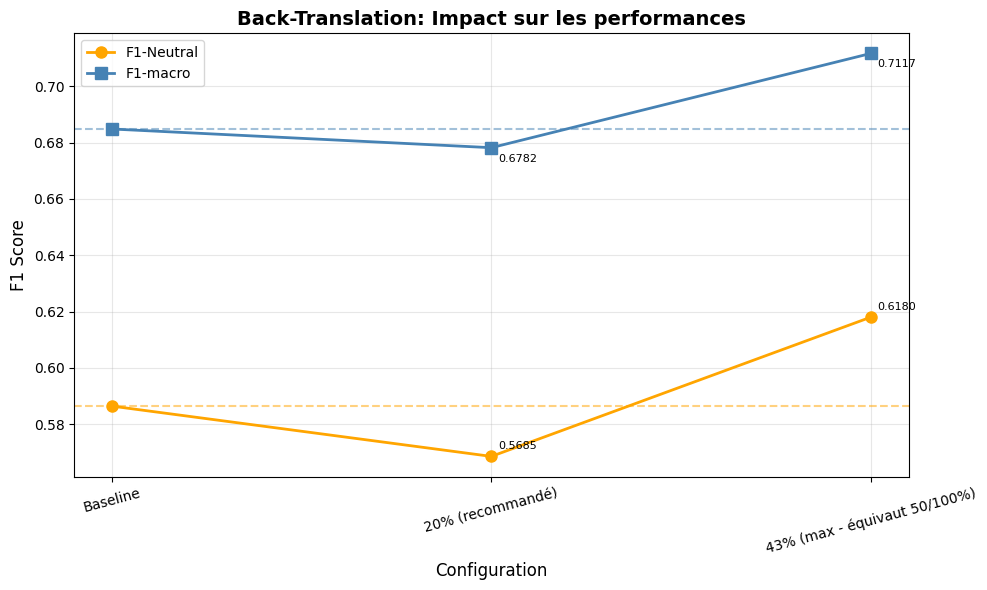

In [35]:
# ============================================================
# STRATÉGIE 3 - BLOC 4 TESTS AVEC TAUX ADAPTÉS
# ============================================================

print("\n" + "="*70)
print("TESTS BACK-TRANSLATION (Taux adaptés sans doublons)")
print("="*70)

# ============================================================
# 1. VÉRIFICATION DES DONNÉES DISPONIBLES
# ============================================================

original_neutral_count = len(neutral_texts)  # 455
available_paraphrases = len(filtered_tweets)  # 196

print(f"\nTweets Neutral originaux: {original_neutral_count}")
print(f"Paraphrases disponibles après filtrage: {available_paraphrases}")
print(f"Taux maximum réalisable: {available_paraphrases/original_neutral_count*100:.1f}%")

# ============================================================
# 2. DÉFINITION DES TAUX ADAPTÉS (SANS DOUBLONS)
# ============================================================

# Taux adaptés à la réalité des données
# 20% = recommandé par le sujet
# 43% = maximum réalisable (équivaut à la limite de 50/100%)
augmentation_tests = [
    {'name': '20% (recommandé)', 'rate': 0.20, 'paraphrases': int(original_neutral_count * 0.20)},
    {'name': '43% (max - équivaut 50/100%)', 'rate': available_paraphrases/original_neutral_count, 'paraphrases': available_paraphrases}
]

print("\nTaux à tester:")
for test in augmentation_tests:
    print(f"  • {test['name']}: {test['paraphrases']} paraphrases ({test['rate']*100:.0f}%)")

# ============================================================
# 3. CRÉATION DES TRAIN SETS AUGMENTÉS
# ============================================================

print("\n" + "="*50)
print("CRÉATION DES DATASETS AUGMENTÉS")
print("="*50)

augmented_datasets = []

for test in augmentation_tests:
    print(f"\n▶ {test['name']}")
    print(f"   Paraphrases à ajouter: {test['paraphrases']}")

    # Sélectionner les paraphrases (sans doublons)
    selected = filtered_tweets[:test['paraphrases']]

    # Créer nouveau train set
    train_augmented = train_set.copy()

    # Ajouter les paraphrases
    new_rows = []
    for p in selected:
        new_rows.append({
            'clean_text': p['back_translated'],
            'Polarity Class': 'Neutral'
        })

    df_new = pd.DataFrame(new_rows)
    train_augmented = pd.concat([train_augmented, df_new], ignore_index=True)

    augmented_datasets.append({
        'name': test['name'],
        'rate': test['rate'],
        'train_set': train_augmented,
        'neutral_original': original_neutral_count,
        'neutral_new': len(selected),
        'neutral_total': original_neutral_count + len(selected)
    })

    print(f"    Neutral: {original_neutral_count} → {original_neutral_count + len(selected)} (+{len(selected)})")
    print(f"    Taille totale train set: {len(train_augmented)}")

# ============================================================
# 4. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

print("\n" + "="*70)
print("ENTRAÎNEMENT ET ÉVALUATION")
print("="*70)

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")

# Mapping des labels
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

final_results = []

for aug in augmented_datasets:
    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {aug['name']}")
    print(f"{'='*50}")

    # Préparer les datasets
    train_aug = aug['train_set']
    train_aug["label"] = train_aug["Polarity Class"].str.lower().map(label2id)

    # Datasets HuggingFace
    train_dataset = Dataset.from_pandas(train_aug[["clean_text", "label"]])
    val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
    test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])

    # Tokenisation
    def tokenize_function(examples):
        return tokenizer(examples["clean_text"], padding="max_length",
                        truncation=True, max_length=128)

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    # Charger modèle
    model = AutoModelForSequenceClassification.from_pretrained(
        "alger-ia/dziribert",
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )

    # Métriques
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        f1_macro = f1_score(labels, predictions, average='macro')
        f1_per_class = f1_score(labels, predictions, average=None)
        return {
            'f1_macro': f1_macro,
            'f1_neutral': f1_per_class[1],
        }

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./backtrans_{aug['name'].replace('%', '').replace(' ', '_')}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        seed=42,
        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    # Entraînement
    trainer.train()

    # Évaluation
    test_results = trainer.evaluate(test_dataset)

    final_results.append({
        'name': aug['name'],
        'rate': aug['rate'],
        'paraphrases_added': aug['neutral_new'],
        'neutral_total': aug['neutral_total'],
        'f1_macro': test_results['eval_f1_macro'],
        'f1_neutral': test_results['eval_f1_neutral']
    })

    print(f"\n Résultats:")
    print(f"   F1-macro: {test_results['eval_f1_macro']:.4f}")
    print(f"   F1-Neutral: {test_results['eval_f1_neutral']:.4f}")

# ============================================================
# 5. TABLEAU COMPARATIF FINAL
# ============================================================

print("\n" + "="*70)
print("TABLEAU COMPARATIF BACK-TRANSLATION")
print("="*70)

import json
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

comparison = pd.DataFrame({
    'Configuration': ['Baseline'] + [r['name'] for r in final_results],
    'Augmentation': ['-'] + [f"{r['rate']*100:.0f}%" for r in final_results],
    'Paraphrases ajoutées': [0] + [r['paraphrases_added'] for r in final_results],
    'F1-macro': [baseline['f1_macro']] + [r['f1_macro'] for r in final_results],
    'F1-Neutral': [baseline['f1_neutral']] + [r['f1_neutral'] for r in final_results]
})

print(comparison.to_string(index=False))

# ============================================================
# 6. GRAPHIQUE
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

configs = comparison['Configuration'].tolist()
f1_neutral = comparison['F1-Neutral'].tolist()
f1_macro = comparison['F1-macro'].tolist()

x = range(len(configs))
ax.plot(x, f1_neutral, 'o-', label='F1-Neutral', linewidth=2, markersize=8, color='orange')
ax.plot(x, f1_macro, 's-', label='F1-macro', linewidth=2, markersize=8, color='steelblue')

ax.axhline(y=baseline['f1_neutral'], color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=baseline['f1_macro'], color='steelblue', linestyle='--', alpha=0.5)

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Back-Translation: Impact sur les performances', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3)

for i, (neu, mac) in enumerate(zip(f1_neutral[1:], f1_macro[1:])):
    ax.annotate(f'{neu:.4f}', (i+1, neu), xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.annotate(f'{mac:.4f}', (i+1, mac), xytext=(5, -10), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

